# Initialization

In [58]:
import pandas as pd
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

load_dotenv()

engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASS')}@{os.getenv('DB_HOST')}:5432/{os.getenv('DB_NAME')}"
)

### Combining the recent_tables and its audio features

In [30]:
df_all = pd.read_sql("""
SELECT 
    a.name,
    a.acousticness,
    a.danceability,
    a.energy,
    a.instrumentalness,
    a.key,
    a.liveness,
    a.mode,
    a.speechiness,
    a.valence,
    a.tempo,
    b.album_name,
    b.played_at,
    b.collection_date
FROM recent_tracks_audio_features a
INNER JOIN recent_tracks b
    ON a.id = b.track_id;
""", engine)

df_all.describe()

,acousticness,danceability,energy,instrumentalness,key,liveness,mode,speechiness,valence
count,522.000000,522.000000,522.000000,522.000000,522.000000,522.000000,522.000000,522.000000,522.000000
mean,0.194494,0.732082,0.602579,0.089238,5.068966,0.200909,0.591954,0.162926,0.475843
std,0.235451,0.152810,0.186334,0.239082,3.600362,0.147663,0.491943,0.129495,0.272180
min,0.000054,0.161000,0.112000,0.000000,0.000000,0.044100,0.000000,0.026100,0.030200
25%,0.039900,0.625000,0.498000,0.000000,1.000000,0.107000,0.000000,0.054000,0.214000
50%,0.080400,0.764000,0.611000,0.000017,5.000000,0.132000,1.000000,0.117000,0.450000
75%,0.313000,0.871000,0.727000,0.000454,8.000000,0.292000,1.000000,0.288000,0.698000
max,0.984000,0.920000,0.999000,0.972000,11.000000,0.859000,1.000000,0.539000,0.972000


### Analyzing daily listening volume

,plays
count,20.000000
mean,46.550000
std,4.071402
min,36.000000
25%,45.000000
50%,48.000000
75%,50.000000
max,50.000000


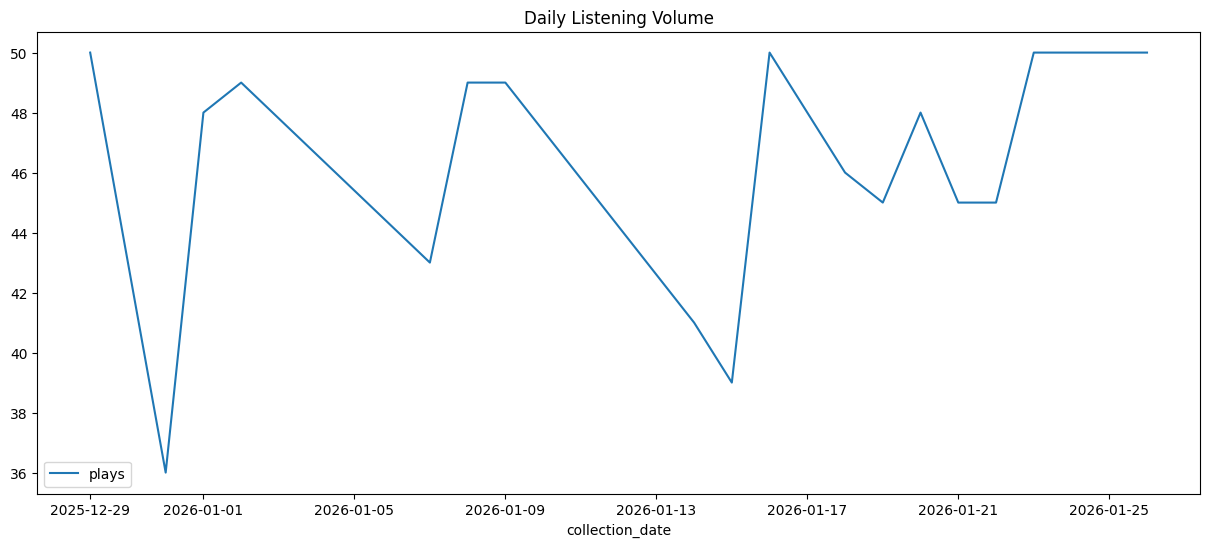

In [ ]:
df = pd.read_sql("""
SELECT collection_date, COUNT(*) AS plays
FROM recent_tracks
WHERE collection_date >= '2025-12-29'
GROUP BY collection_date
ORDER BY collection_date
""", engine)

df.plot(x="collection_date", y="plays", title="Daily Listening Volume", figsize=(15, 6))

In [40]:
df.describe()

,plays
count,20.000000
mean,46.550000
std,4.071402
min,36.000000
25%,45.000000
50%,48.000000
75%,50.000000
max,50.000000


From the graph, we can see that the plays are typically around 50 with the max being 50 plays a day and a mean of 46 plays a day. The lowest amount of plays per day was 36.

### Analyzing number of unique plays

We want to look at the unique number of tracks played per day to see if the user is repeating listening or exploring new songs often.

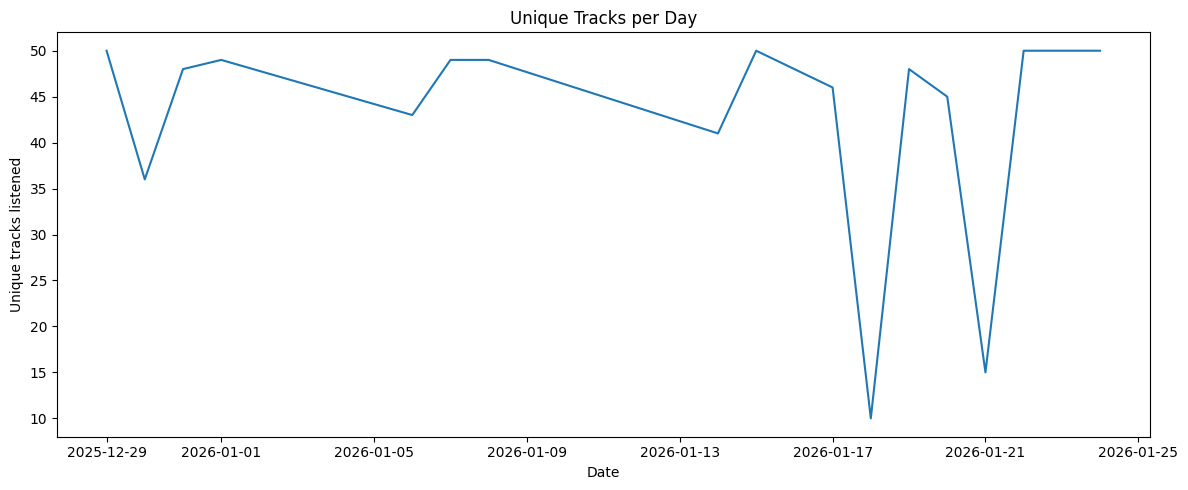

In [47]:
df = pd.read_sql("""
SELECT
    played_at::date AS day,
    COUNT(DISTINCT track_id) AS unique_tracks
FROM recent_tracks
WHERE played_at >= '2025-12-29'
GROUP BY day
ORDER BY day;
""", engine)

plt.figure(figsize=(12, 5))
plt.plot(df["day"], df["unique_tracks"])
plt.xlabel("Date")
plt.ylabel("Unique tracks listened")
plt.title("Unique Tracks per Day")
plt.tight_layout()
plt.show()

This is another plot of unique plays across the user's whole listening history and not just per day.

<Axes: title={'center': 'New (Globally Unique) Tracks per Day'}, xlabel='day'>

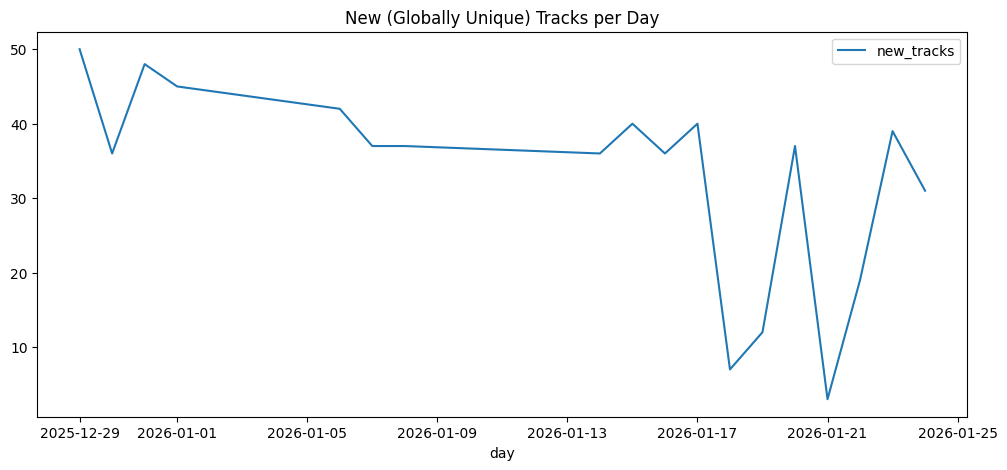

In [48]:
df = pd.read_sql("""
    SELECT track_id, played_at::date AS day
    FROM recent_tracks
    WHERE played_at IS NOT NULL AND played_at >= '2025-12-29'
""", engine)

df["first_day"] = df.groupby("track_id")["day"].transform("min")

new_tracks_per_day = (
    df[df["day"] == df["first_day"]]
    .groupby("day")["track_id"]
    .nunique()
    .reset_index(name="new_tracks")
)


new_tracks_per_day.plot(
    x="day",
    y="new_tracks",
    figsize=(12, 5),
    title="New (Globally Unique) Tracks per Day"
)


We can see that the user explores new tracks often.

### Exploring recent top tracks and artists

<Axes: title={'center': 'Daily Listening Volume'}, xlabel='track_name'>

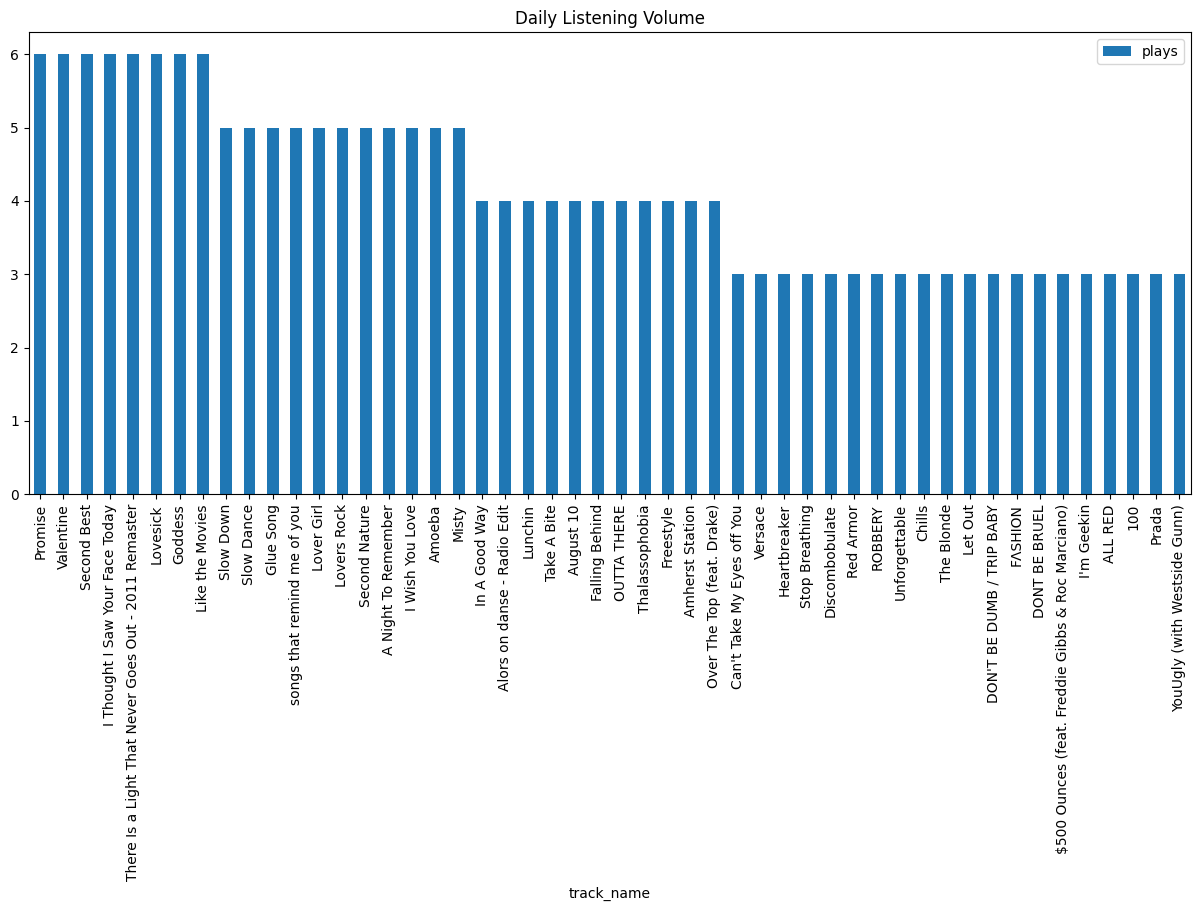

In [49]:
df = pd.read_sql("""
SELECT track_name, COUNT(*) AS plays
FROM recent_tracks
WHERE collection_date >= '2025-12-29'
GROUP BY track_name
ORDER BY plays DESC
LIMIT 50;
""", engine)

# for artists with $ in their names
# df["artist_name"] = df["artist_name"].str.replace("$", r"\$", regex=False)

df.plot(
    x="track_name",
    y="plays",
    title=r"Daily Listening Volume",
    figsize=(15, 6),
    kind="bar"
)


<Axes: title={'center': 'Daily Listening Volume'}, xlabel='artist_name'>

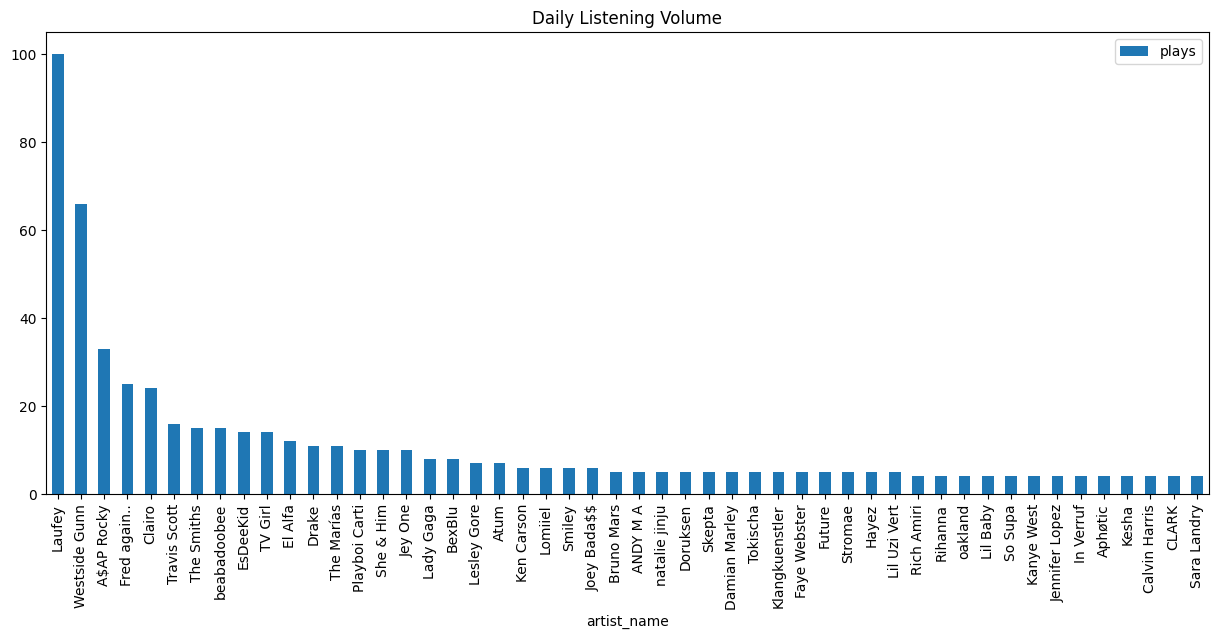

In [50]:
df = pd.read_sql("""
SELECT artist_name, COUNT(*) AS plays
FROM recent_tracks
WHERE collection_date >= '2025-12-29'
GROUP BY artist_name
ORDER BY plays DESC
LIMIT 50;
""", engine)

# for artists with $ in their names
df["artist_name"] = df["artist_name"].str.replace("$", r"\$", regex=False)

df.plot(
    x="artist_name",
    y="plays",
    title=r"Daily Listening Volume",
    figsize=(15, 6),
    kind="bar"
)


### Audio Features Distributions

<Axes: ylabel='Density'>

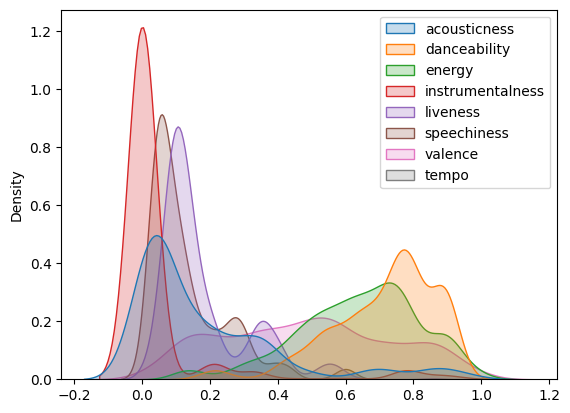

In [51]:
features = [
    "acousticness", "danceability", "energy",
    "instrumentalness", "liveness",
    "speechiness", "valence", "tempo"
]

df = pd.read_sql("""
SELECT * FROM recent_tracks_audio_features;
""", engine)

# df[features].hist(bins=30, figsize=(14,10))
sns.kdeplot(data=df[features], fill=True) # for kde plot

array([[<Axes: title={'center': 'acousticness'}>,
        <Axes: title={'center': 'danceability'}>,
        <Axes: title={'center': 'energy'}>],
       [<Axes: title={'center': 'instrumentalness'}>,
        <Axes: title={'center': 'liveness'}>,
        <Axes: title={'center': 'speechiness'}>],
       [<Axes: title={'center': 'valence'}>, <Axes: >, <Axes: >]],
      dtype=object)

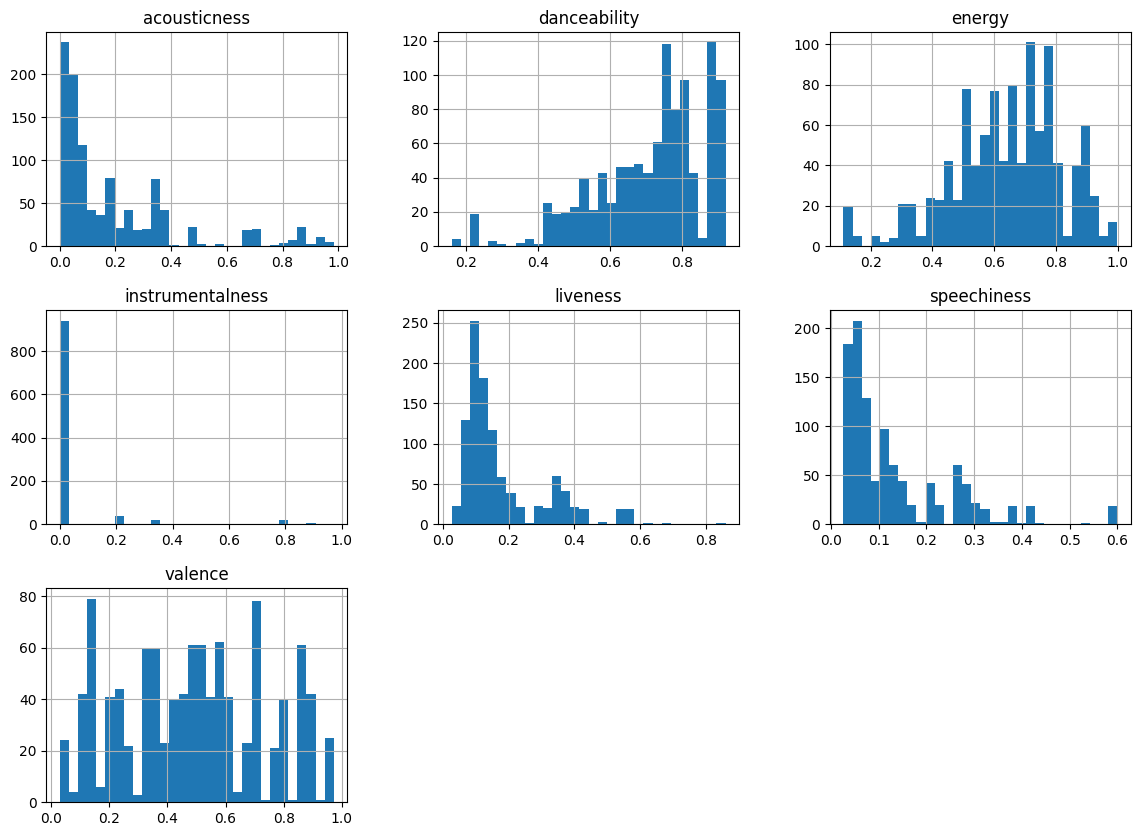

In [52]:
features = [
    "acousticness", "danceability", "energy",
    "instrumentalness", "liveness",
    "speechiness", "valence", "tempo"
]

df = pd.read_sql("""
SELECT * FROM recent_tracks_audio_features;
""", engine)

df[features].hist(bins=30, figsize=(14,10))
# sns.kdeplot(data=df[features], fill=True) # for kde plot

In [53]:
df[features].corr().round(2)

,acousticness,danceability,energy,instrumentalness,liveness,speechiness,valence,tempo
acousticness,1.00,-0.15,-0.46,0.00,0.06,0.24,0.11,NaN
danceability,-0.15,1.00,0.01,-0.18,-0.13,0.22,0.37,NaN
energy,-0.46,0.01,1.00,0.06,0.00,-0.17,0.36,NaN
instrumentalness,0.00,-0.18,0.06,1.00,-0.02,-0.00,-0.16,NaN
liveness,0.06,-0.13,0.00,-0.02,1.00,0.20,-0.04,NaN
speechiness,0.24,0.22,-0.17,-0.00,0.20,1.00,0.07,NaN
valence,0.11,0.37,0.36,-0.16,-0.04,0.07,1.00,NaN
tempo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


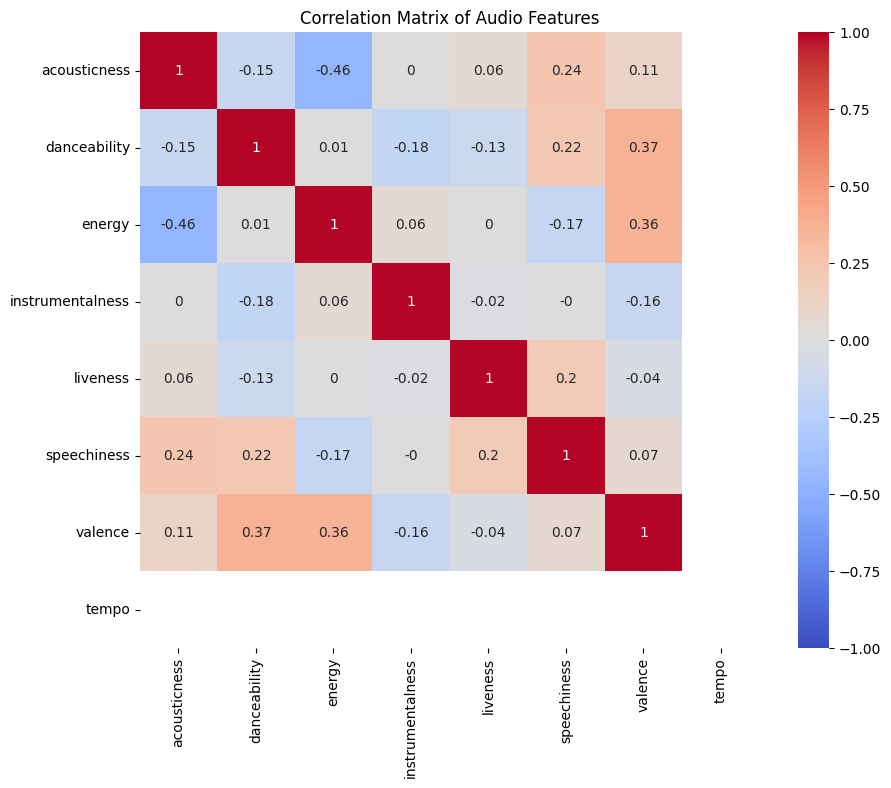

In [54]:
df_corr = df[features].corr().round(2)
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Audio Features")
plt.show()

### Heading

In [66]:
X = df[features]
print(X)
# X = X[~pd.isnull(X).any(axis=1)]  # Remove rows with NaN values
# X = X.dropna(how='all')


# X_scaled = StandardScaler().fit_transform(X)

# pca = PCA(n_components=2)
# X_reduced = pca.fit_transform(X_scaled)

# plt.figure(figsize=(10, 7))
# plt.scatter(X_reduced[:, 0], X_reduced[:, 1], alpha=0.5)
# plt.title("PCA of Audio Features")
# plt.xlabel("Principal Component 1")
# plt.ylabel("Principal Component 2")
# plt.grid()
# plt.show()

      acousticness  danceability  energy  instrumentalness  liveness  \
0           0.0622         0.673   0.962          0.893000    0.0843   
1           0.0355         0.634   0.907          0.972000    0.1290   
2           0.0243         0.829   0.722          0.741000    0.1260   
3           0.4200         0.561   0.998          0.173000    0.6690   
4           0.0196         0.609   0.912          0.478000    0.1330   
...            ...           ...     ...               ...       ...   
1078        0.0097         0.515   0.430          0.000133    0.1290   
1079        0.0137         0.482   0.757          0.001600    0.1430   
1080        0.3590         0.882   0.764          0.000000    0.1190   
1081        0.7150         0.802   0.384          0.000686    0.1080   
1082        0.4750         0.882   0.645          0.000041    0.0570   

      speechiness  valence tempo  
0          0.0637   0.1240  None  
1          0.1250   0.0502  None  
2          0.2560   0.4290  No

### Heading

array([[<Axes: title={'center': 'acousticness'}>,
        <Axes: title={'center': 'danceability'}>,
        <Axes: title={'center': 'energy'}>],
       [<Axes: title={'center': 'instrumentalness'}>,
        <Axes: title={'center': 'liveness'}>,
        <Axes: title={'center': 'speechiness'}>],
       [<Axes: title={'center': 'valence'}>, <Axes: >, <Axes: >]],
      dtype=object)

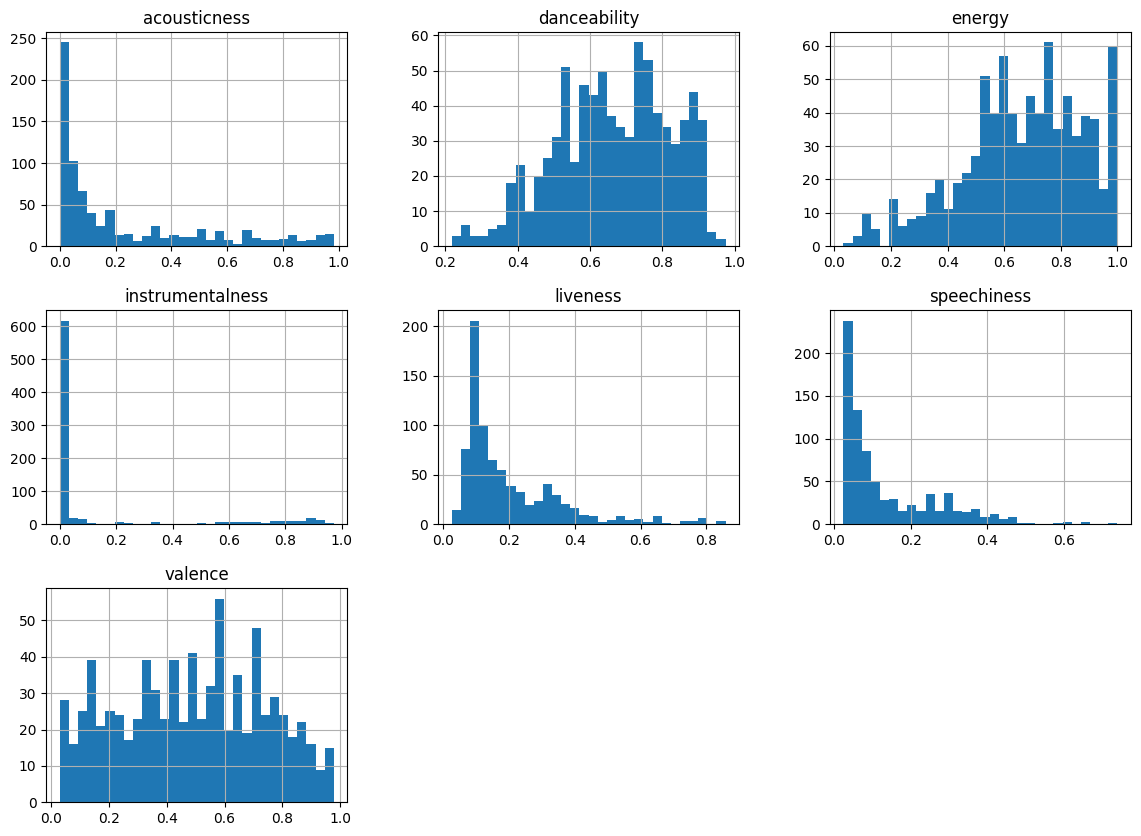

In [38]:
features = [
    "acousticness", "danceability", "energy",
    "instrumentalness", "liveness",
    "speechiness", "valence", "temp"
]

df = pd.read_sql("""
SELECT * FROM top_tracks_audio_features;
""", engine)

df[features].hist(bins=30, figsize=(14,10))